In [1]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
from QiskitTranspiler.transpiler.transpile import transpile

Circuit Depth: 15


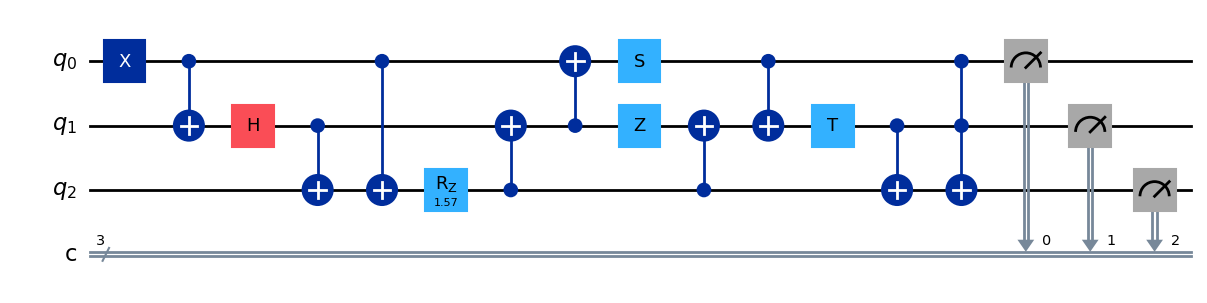

In [3]:
qc = QuantumCircuit(3, 3)

# Depth 1-5
qc.x(0)
qc.cx(0, 1)
qc.h(1)
qc.cx(1, 2)
qc.cx(0, 2)

qc.rz(1.57, 2)
qc.cx(2, 1)
qc.cx(1, 0)
qc.z(1)
qc.cx(2, 1)

qc.s(0)
qc.cx(0, 1)
qc.t(1) 
qc.cx(1, 2)
qc.ccx(0, 1, 2)

qc.measure([0, 1, 2], [0, 1, 2])

print(f"Circuit Depth: {qc.depth()}")
qc.draw("mpl")

In [4]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

#Testing first with a simulator, then with a real backend
backend = FakeFez()

transpiled_circuit = transpile(qc, backend)
print(backend.basis_gates)
print(backend.coupling_map) 
# transpiled_circuit.draw("mpl")

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'
['cz', 'id', 'rz', 'sx', 'x']
[[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 4], [3, 16], [4, 3], [4, 5], [5, 4], [5, 6], [6, 5], [6, 7], [7, 6], [7, 8], [7, 17], [8, 7], [8, 9], [9, 8], [9, 10], [10, 9], [10, 11], [11, 10], [11, 12], [11, 18], [12, 11], [12, 13], [13, 12], [13, 14], [14, 13], [14, 15], [15, 14], [15, 19], [16, 3], [16, 23], [17, 7], [17, 27], [18, 11], [18, 31], [19, 15], [19, 35], [20, 21], [21, 20], [21, 22], [21, 36], [22, 21], [22, 23], [23, 16], [23, 22], [23, 24], [24, 23], [24, 25], [25, 24], [25, 26], [25, 37], [26, 25], [26, 27], [27, 17], [27, 26], [27, 28], [28, 27], [28, 29], [29, 28], [29, 30], [29, 38], [30, 29], [30, 31], [31, 18], [31, 30], [31, 32], [32, 31], [32, 33], [33, 32], [33, 34], [33, 39], [34, 33], [34, 35], [35, 19], [35, 34], [36, 21], [36, 41], [37, 25], [37, 45], [38, 29], [38, 49], [39, 33], [39, 53], [40, 41], [41, 3

In [9]:
sampler = Sampler(mode=backend)

experiment_accuracies = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "100" and state != "110":
            acc_sum += count
    accuracy = acc_sum / 1024
    experiment_accuracies.append(accuracy)

print("Average accuracy over 50 runs:", sum(experiment_accuracies) / len(experiment_accuracies))
print("Accuracies for each run:", experiment_accuracies)

Average accuracy over 50 runs: 0.05625
Accuracies for each run: [0.0556640625, 0.04296875, 0.0546875, 0.0693359375, 0.0546875, 0.044921875, 0.068359375, 0.0498046875, 0.05859375, 0.052734375, 0.05078125, 0.0537109375, 0.06640625, 0.068359375, 0.0458984375, 0.048828125, 0.056640625, 0.072265625, 0.0517578125, 0.0478515625, 0.0654296875, 0.0615234375, 0.06640625, 0.0498046875, 0.07421875, 0.052734375, 0.056640625, 0.0537109375, 0.052734375, 0.056640625, 0.0576171875, 0.060546875, 0.060546875, 0.0546875, 0.0615234375, 0.044921875, 0.0517578125, 0.0595703125, 0.05078125, 0.046875, 0.0625, 0.0556640625, 0.052734375, 0.0517578125, 0.0595703125, 0.0537109375, 0.0546875, 0.0595703125, 0.0595703125, 0.0498046875]


In [1]:
import numpy as np
errors = [0.0556640625, 0.04296875, 0.0546875, 0.0693359375, 0.0546875, 0.044921875, 0.068359375, 0.0498046875, 0.05859375, 0.052734375, 0.05078125, 0.0537109375, 0.06640625, 0.068359375, 0.0458984375, 0.048828125, 0.056640625, 0.072265625, 0.0517578125, 0.0478515625, 0.0654296875, 0.0615234375, 0.06640625, 0.0498046875, 0.07421875, 0.052734375, 0.056640625, 0.0537109375, 0.052734375, 0.056640625, 0.0576171875, 0.060546875, 0.060546875, 0.0546875, 0.0615234375, 0.044921875, 0.0517578125, 0.0595703125, 0.05078125, 0.046875, 0.0625, 0.0556640625, 0.052734375, 0.0517578125, 0.0595703125, 0.0537109375, 0.0546875, 0.0595703125, 0.0595703125, 0.0498046875]
mean_error = np.mean(errors)
print("Mean error over 50 runs:", mean_error)
std = np.std(errors)
print("Standard deviation of errors over 50 runs:", std)
ci95 = 1.96 * std / np.sqrt(len(errors))
print(f"{mean_error:.4f} ± {ci95:.4f} (95% CI)")

Mean error over 50 runs: 0.05625
Standard deviation of errors over 50 runs: 0.00720541669753778
0.0563 ± 0.0020 (95% CI)


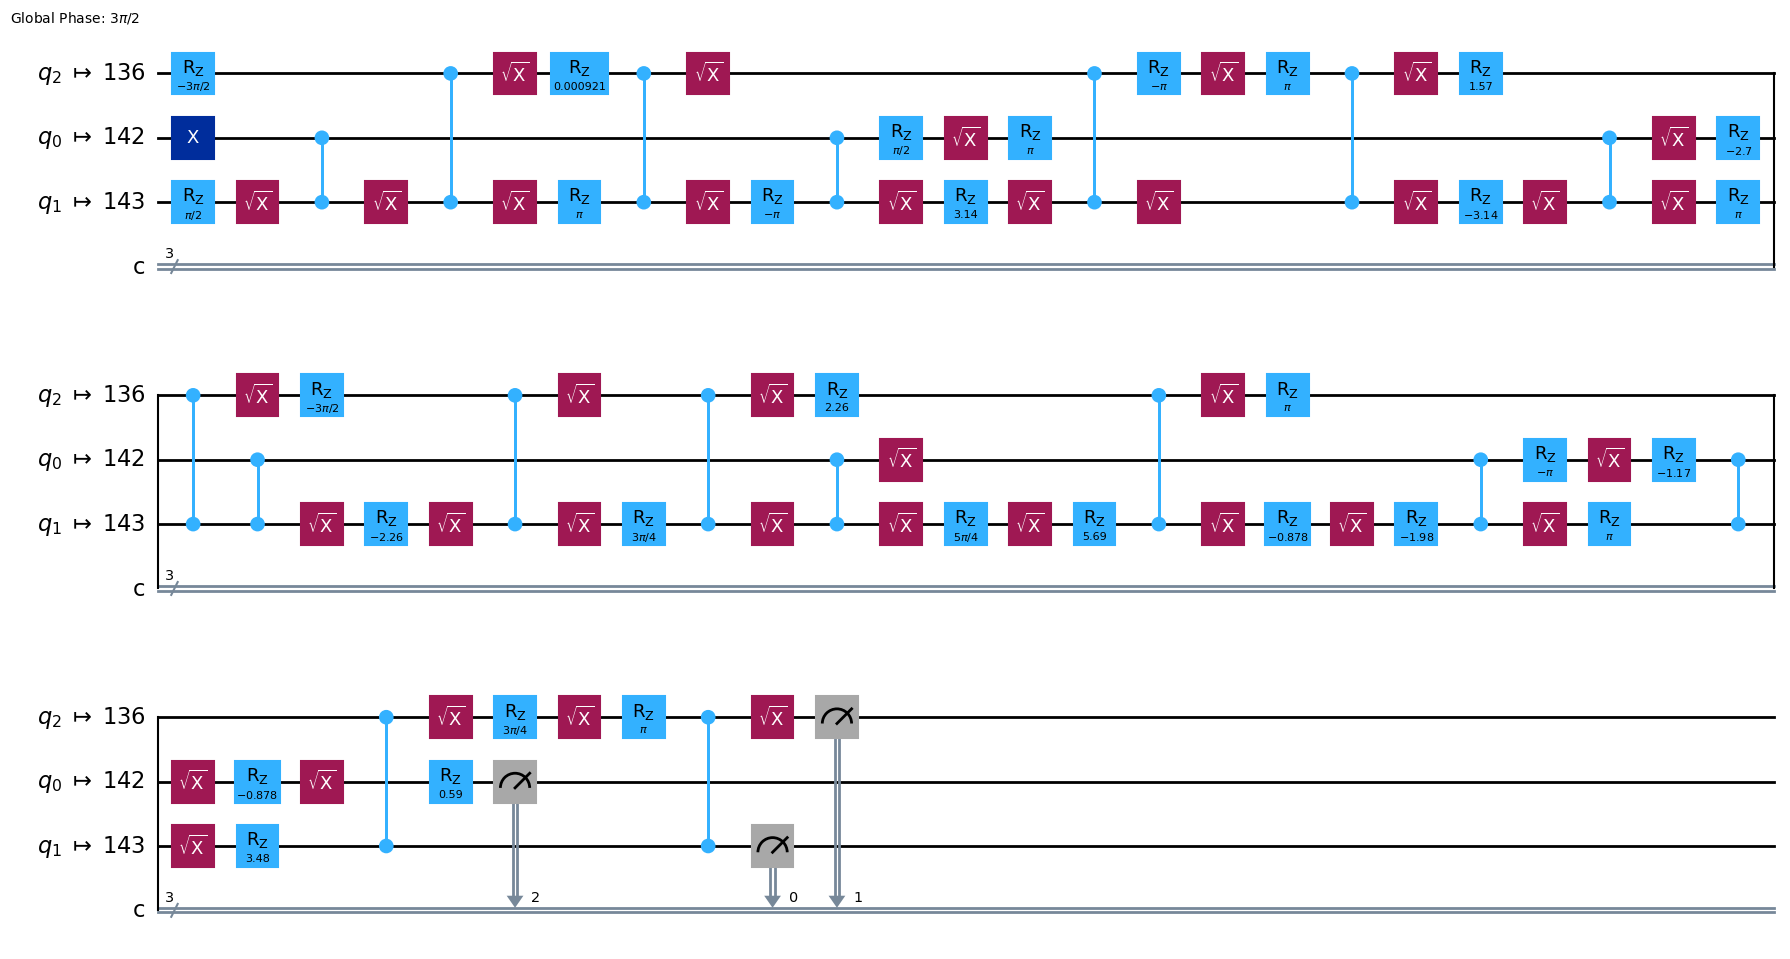

In [5]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import transpile

#Testing first with a simulator, then with a real backend
backend = FakeFez()

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")

In [7]:
sampler = Sampler(mode=backend)

experiment_errors = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "100" and state != "110":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)

print("Average error over 50 runs (Qiskit transpiler):", sum(experiment_errors) / len(experiment_errors))
print("Errors for each run:", experiment_errors)

Average error over 50 runs (Qiskit transpiler): 0.0510546875
Errors for each run: [0.0615234375, 0.048828125, 0.0478515625, 0.0419921875, 0.04296875, 0.0439453125, 0.0439453125, 0.048828125, 0.0478515625, 0.0439453125, 0.0517578125, 0.0634765625, 0.046875, 0.0654296875, 0.0703125, 0.044921875, 0.0498046875, 0.052734375, 0.0625, 0.056640625, 0.0498046875, 0.06640625, 0.0546875, 0.0517578125, 0.0419921875, 0.0537109375, 0.04296875, 0.048828125, 0.0478515625, 0.0537109375, 0.04296875, 0.0498046875, 0.056640625, 0.0537109375, 0.0478515625, 0.056640625, 0.0458984375, 0.0390625, 0.0556640625, 0.052734375, 0.052734375, 0.046875, 0.052734375, 0.0595703125, 0.0400390625, 0.05078125, 0.0458984375, 0.0576171875, 0.048828125, 0.048828125]


In [3]:
import numpy as np
errors = [0.0615234375, 0.048828125, 0.0478515625, 0.0419921875, 0.04296875, 0.0439453125, 0.0439453125, 0.048828125, 0.0478515625, 0.0439453125, 0.0517578125, 0.0634765625, 0.046875, 0.0654296875, 0.0703125, 0.044921875, 0.0498046875, 0.052734375, 0.0625, 0.056640625, 0.0498046875, 0.06640625, 0.0546875, 0.0517578125, 0.0419921875, 0.0537109375, 0.04296875, 0.048828125, 0.0478515625, 0.0537109375, 0.04296875, 0.0498046875, 0.056640625, 0.0537109375, 0.0478515625, 0.056640625, 0.0458984375, 0.0390625, 0.0556640625, 0.052734375, 0.052734375, 0.046875, 0.052734375, 0.0595703125, 0.0400390625, 0.05078125, 0.0458984375, 0.0576171875, 0.048828125, 0.048828125]
mean_error = np.mean(errors)
print("Mean error over 50 runs:", mean_error)
std = np.std(errors)
print("Standard deviation of errors over 50 runs:", std)
ci95 = 1.96 * std / np.sqrt(len(errors))
print(f"{mean_error:.4f} ± {ci95:.4f} (95% CI)")

Mean error over 50 runs: 0.0510546875
Standard deviation of errors over 50 runs: 0.007012344374944267
0.0511 ± 0.0019 (95% CI)


In [8]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

# See all available backends
for b in service.backends():
    print(b.name, b.num_qubits, b.status().pending_jobs)

ibm_fez 156 2
ibm_marrakesh 156 0
ibm_kingston 156 0


In [9]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from QiskitTranspiler.transpiler.transpile import transpile

transpiled_circuit = transpile(qc, backend)
# transpiled_circuit.draw("mpl")

Running on: ibm_fez (156 qubits)
[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


In [10]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7b1hc65nvhs73a2o080
Job ID: d7b1hcb0g7hs73dovumg
Job ID: d7b1hch5a5qc73dmsr7g
Job ID: d7b1hch5a5qc73dmsr8g
Job ID: d7b1hcr0g7hs73dovung
Job ID: d7b1hd3klj2c73eul1og
Job ID: d7b1hd95a5qc73dmsra0
Job ID: d7b1hdm5nvhs73a2o0ag
Job ID: d7b1hdrklj2c73eul1q0
Job ID: d7b1he65nvhs73a2o0b0


In [11]:
job_ids = [
    "d7b1hc65nvhs73a2o080",
    "d7b1hcb0g7hs73dovumg",
    "d7b1hch5a5qc73dmsr7g",
    "d7b1hch5a5qc73dmsr8g",
    "d7b1hcr0g7hs73dovung",
    "d7b1hd3klj2c73eul1og",
    "d7b1hd95a5qc73dmsra0",
    "d7b1hdm5nvhs73a2o0ag",
    "d7b1hdrklj2c73eul1q0",
    "d7b1he65nvhs73a2o0b0",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "100" and state != "110":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7b1hc65nvhs73a2o080: error = 0.0723
Job d7b1hcb0g7hs73dovumg: error = 0.0693
Job d7b1hch5a5qc73dmsr7g: error = 0.0752
Job d7b1hch5a5qc73dmsr8g: error = 0.0771
Job d7b1hcr0g7hs73dovung: error = 0.0957
Job d7b1hd3klj2c73eul1og: error = 0.0889
Job d7b1hd95a5qc73dmsra0: error = 0.0928
Job d7b1hdm5nvhs73a2o0ag: error = 0.1006
Job d7b1hdrklj2c73eul1q0: error = 0.0801
Job d7b1he65nvhs73a2o0b0: error = 0.0752

Average error over runs: 0.08271484375


Running on: ibm_fez (156 qubits)


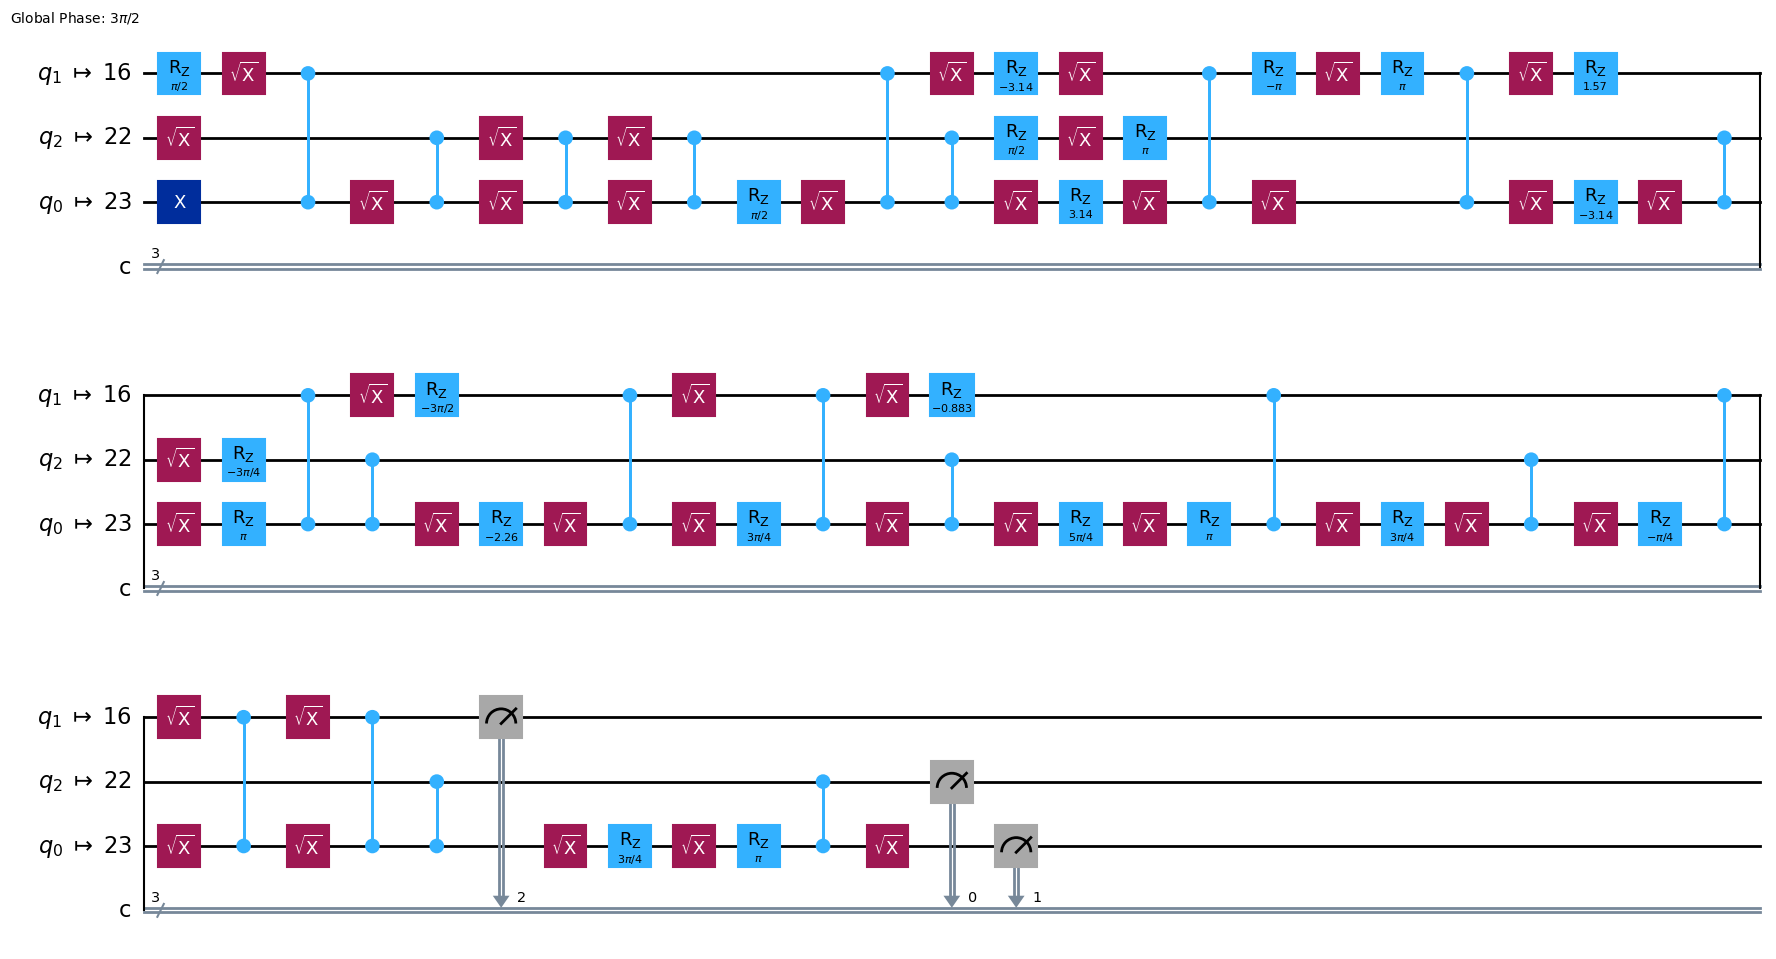

In [12]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from qiskit import transpile

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")

In [13]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7b1idh5a5qc73dmssf0
Job ID: d7b1idrklj2c73eul310
Job ID: d7b1iebklj2c73eul320
Job ID: d7b1iem5nvhs73a2o1mg
Job ID: d7b1ier0g7hs73dovvug
Job ID: d7b1if3klj2c73eul34g
Job ID: d7b1ifjklj2c73eul350
Job ID: d7b1ig3klj2c73eul36g
Job ID: d7b1ig95a5qc73dmsslg
Job ID: d7b1igh5a5qc73dmssmg


In [15]:
job_ids = [
    "d7b1idh5a5qc73dmssf0",
    "d7b1idrklj2c73eul310",
    "d7b1iebklj2c73eul320",
    "d7b1iem5nvhs73a2o1mg",
    "d7b1ier0g7hs73dovvug",
    "d7b1if3klj2c73eul34g",
    "d7b1ifjklj2c73eul350",
    "d7b1ig3klj2c73eul36g",
    "d7b1ig95a5qc73dmsslg",
    "d7b1igh5a5qc73dmssmg",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "100" and state != "110":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7b1idh5a5qc73dmssf0: error = 0.0732
Job d7b1idrklj2c73eul310: error = 0.0605
Job d7b1iebklj2c73eul320: error = 0.0771
Job d7b1iem5nvhs73a2o1mg: error = 0.0703
Job d7b1ier0g7hs73dovvug: error = 0.0889
Job d7b1if3klj2c73eul34g: error = 0.0762
Job d7b1ifjklj2c73eul350: error = 0.0723
Job d7b1ig3klj2c73eul36g: error = 0.0654
Job d7b1ig95a5qc73dmsslg: error = 0.0811
Job d7b1igh5a5qc73dmssmg: error = 0.0820

Average error over runs: 0.07470703125
